In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

In [17]:
def get_season(time_stamp):
    month = int(time_stamp.split('-')[1])
    if 3 <= month <= 5:
        return 'Spring'
    if 6 <= month <= 8:
        return 'Summer'
    if 9 <= month <= 11:
        return 'Fall'
    return 'Winter'

In [91]:
use_cols = ['time_stamp', 'min_wind_speed', 'max_wind_speed', 'min_rotor_speed', 'max_rotor_speed']
seasons = ['Spring', 'Summer', 'Fall', 'Winter']
colors = ['#E8F4C8', '#F7D9C4', '#C7E6F4']
farms = ['A', 'B', 'C']

In [93]:
dfA = pd.read_csv('WindFarmA_combined.csv')[use_cols]
dfB = pd.read_csv('WindFarmB_combined.csv')[use_cols]
dfC = pd.read_csv('WindFarmC_combined.csv')[use_cols]

In [94]:
# create farm indicators
dfA['farm'] = 'A'
dfB['farm'] = 'B'
dfC['farm'] = 'C'

df = pd.concat([dfA, dfB, dfC])
df['season'] = df['time_stamp'].apply(get_season)
df.drop(columns = ['time_stamp'], inplace = True)

In [103]:
def ridge_grid(df, value_col, title):
    # make plot and subplots
    fig, axes = plt.subplots(
        nrows=len(seasons),
        ncols=len(farms),
        figsize=(14, 10),
        sharex=True,
        sharey=True
    )

    for i, season in enumerate(seasons):
        for j, farm in enumerate(farms):

            ax = axes[i, j]

            # extract data for this season × farm
            vals = df.loc[
                (df['season'] == season) &
                (df['farm'] == farm),
                value_col
            ].dropna()

            if len(vals) > 1:
                kde = gaussian_kde(vals)
                x = np.linspace(vals.min() - 1, vals.max() + 1, 400)
                y = kde(x)

                ax.fill_between(x, y, 0, color = colors[j], edgecolor = 'black')

            # labels
            if j == 0:
                ax.set_ylabel(season, fontsize=12)
            if i == 0:
                ax.set_title(f"Farm {farm}", fontsize=12)

            ax.set_yticks([])

    fig.suptitle(title, fontsize=16)
    fig.text(0.5, 0.04, 'Wind Speed (m/s)', ha='center')
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    save_as = title.lower().replace(' ', '_') + '.svg'
    plt.savefig(save_as)
    plt.show()

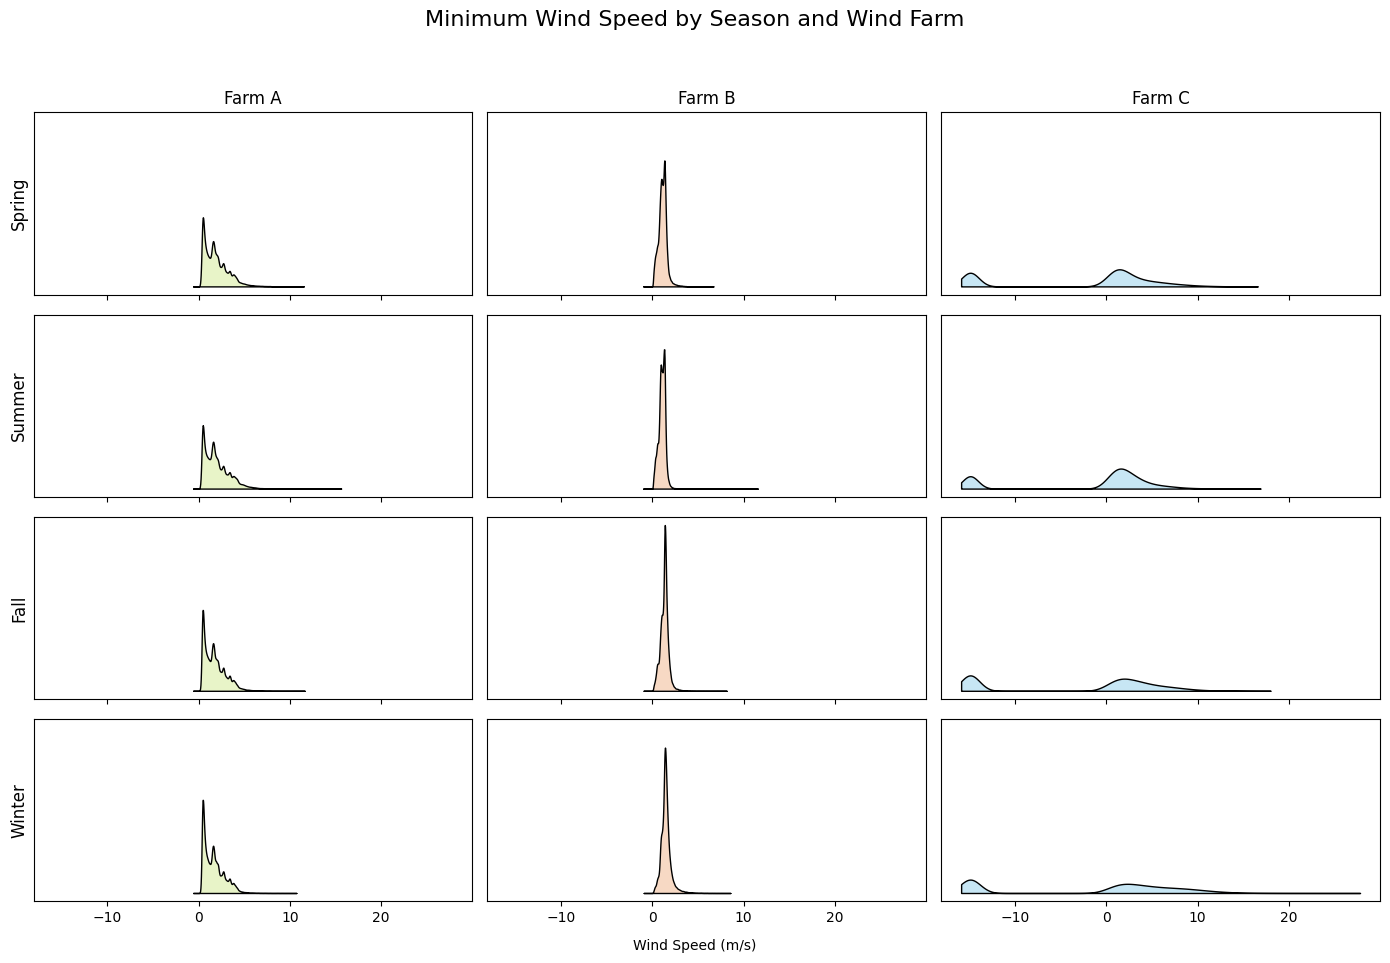

In [104]:
ridge_grid(df, 'min_wind_speed', 'Minimum Wind Speed by Season and Wind Farm')

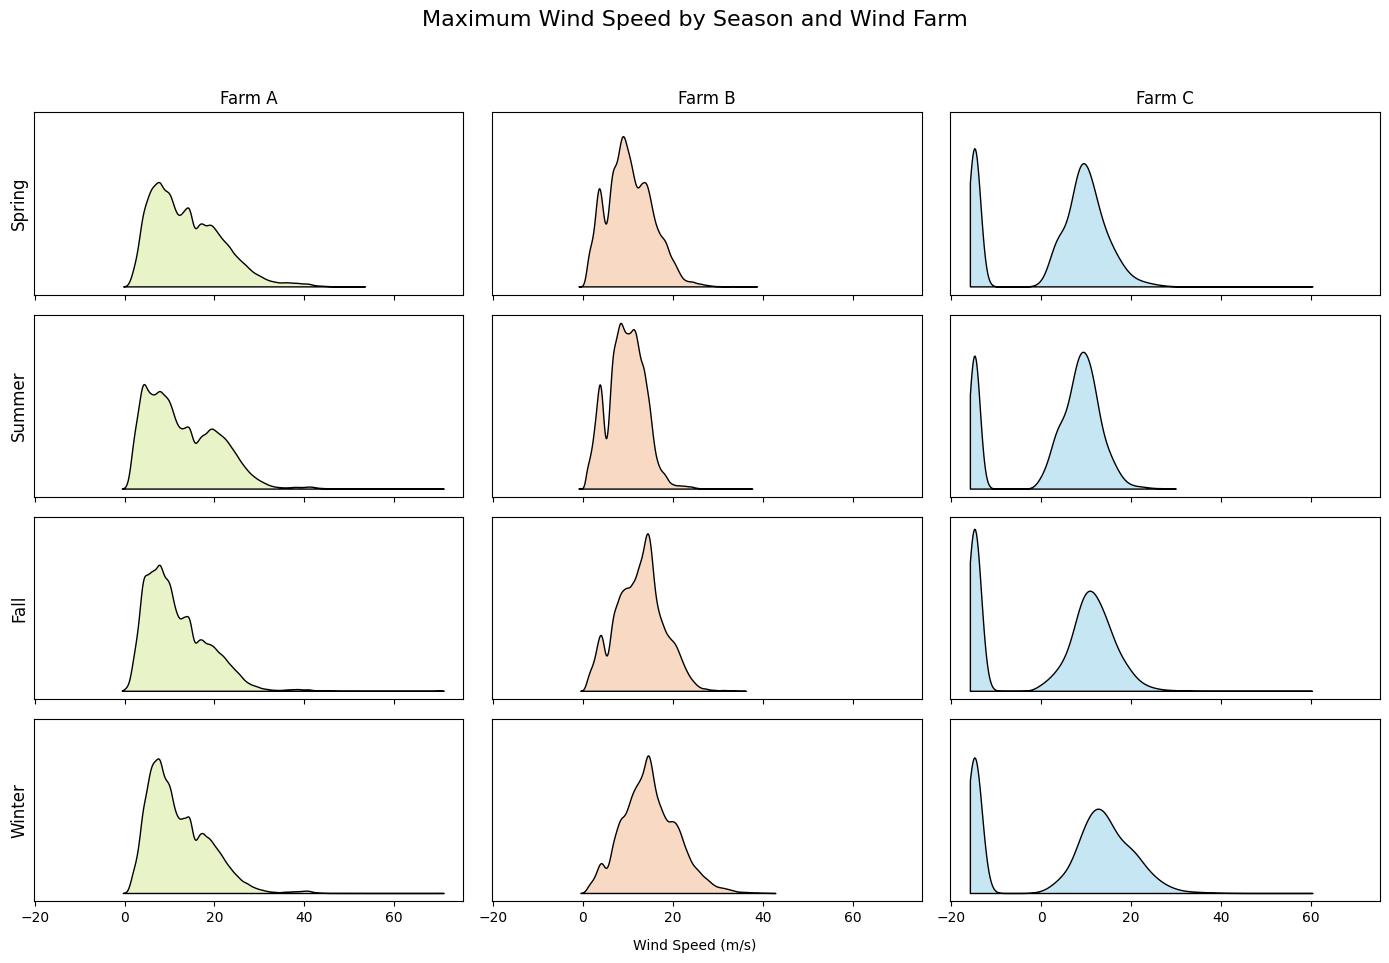

In [105]:
ridge_grid(df, 'max_wind_speed', 'Maximum Wind Speed by Season and Wind Farm')

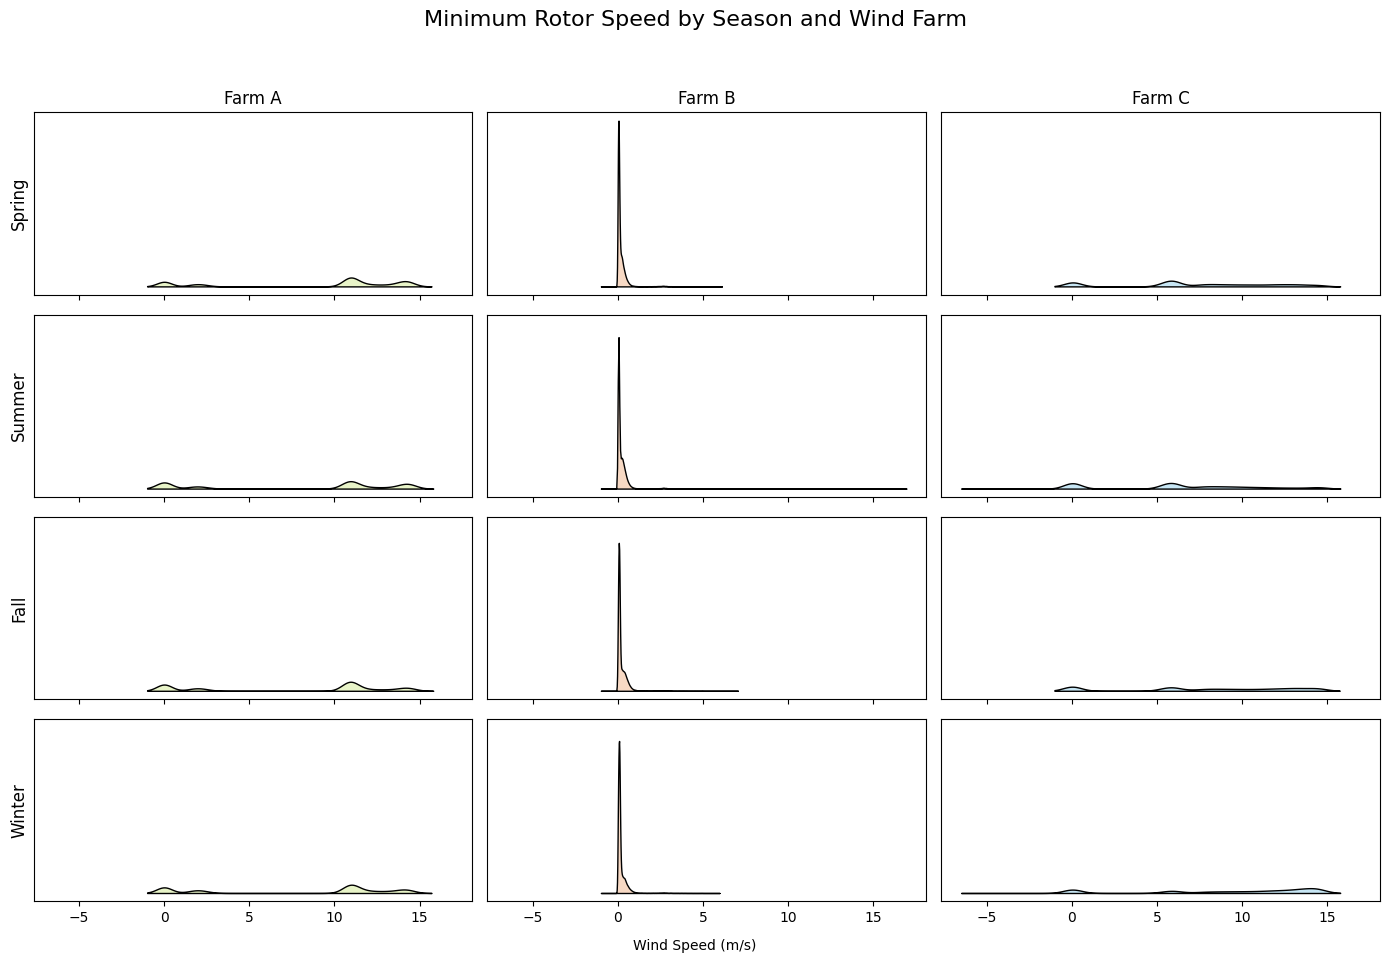

In [106]:
ridge_grid(df, 'min_rotor_speed', 'Minimum Rotor Speed by Season and Wind Farm')

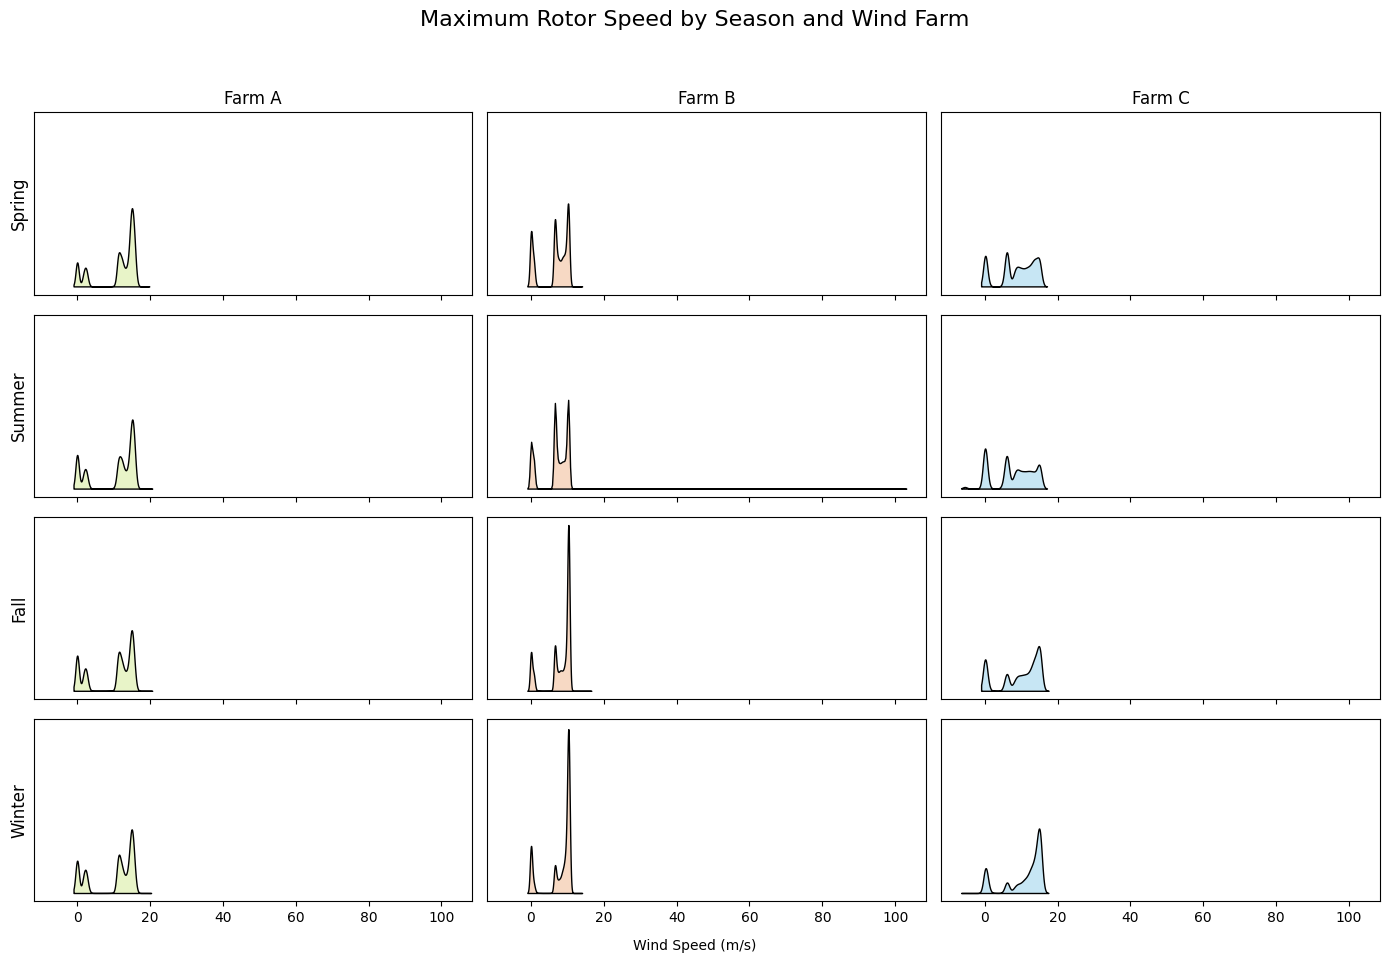

In [107]:
ridge_grid(df, 'max_rotor_speed', 'Maximum Rotor Speed by Season and Wind Farm')